In [1]:
import os, sys

# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)


# Imports
from stn_gpe import *
import numpy as np
from matplotlib import pyplot as plt
import scipy
from numpy.fft import fft, ifft
import math
from scipy.signal import spectrogram
from matplotlib.lines import Line2D

from matplotlib.colors import LinearSegmentedColormap
# rc styling (Times New Roman + nicer defaults)
# ...existing code...
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "font.weight": "bold",         # global bold
    "axes.titlesize": 12,
    "axes.titleweight": "bold",    # bold axis titles
    "axes.labelsize": 11,
    "axes.labelweight": "bold",    # bold axis labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.grid": False
})
# ...existing code...

Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/light_house_DBS_decision_making


## Run STN-GPe system

In [2]:
# Parameters file
yaml_path_normal = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_Normal.yaml')
arguments_normal = load_yaml(yaml_path_normal)


# Simulate STN-GPe system
results_normal = STN_GPe_loop(yaml_path_normal)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [3]:
# Parameters file
yaml_path_PD = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_PD.yaml')
arguments_PD = load_yaml(yaml_path_PD)


# Simulate STN-GPe system
results_PD = STN_GPe_loop(yaml_path_PD)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [4]:
# Parameters file
yaml_path_std_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_std_DBS.yaml')
arguments_std_DBS = load_yaml(yaml_path_std_DBS)


# Simulate STN-GPe system
results_std_DBS = STN_GPe_loop(yaml_path_std_DBS)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [5]:
# Parameters file
yaml_path_sector_DBS = os.path.join(project_root, 'params', 'stn_gpe_params', 'params_sector_DBS.yaml')
arguments_sector_DBS = load_yaml(yaml_path_sector_DBS)


# Simulate STN-GPe system
results_sector_DBS = STN_GPe_loop(yaml_path_sector_DBS)

  0%|          | 0/50000 [00:00<?, ?it/s]

## Analysis

In [6]:
V_stn_time_all_normal = np.array(results_normal['v_stn'])
V_gpe_time_all_normal = np.array(results_normal['v_gpe'])
spike_monitor_stn_normal = results_normal['spike_stn']
spike_monitor_gpe_normal = results_normal['spike_gpe']
lfp_stn_normal = results_normal['lfp_stn']
lfp_gpe_normal = results_normal['lfp_gpe']


V_stn_time_all_PD = np.array(results_PD['v_stn'])
V_gpe_time_all_PD = np.array(results_PD['v_gpe'])
spike_monitor_stn_PD = results_PD['spike_stn']
spike_monitor_gpe_PD = results_PD['spike_gpe']
lfp_stn_PD = results_PD['lfp_stn']
lfp_gpe_PD = results_PD['lfp_gpe']


V_stn_time_all_std_DBS = np.array(results_std_DBS['v_stn'])
V_gpe_time_all_std_DBS = np.array(results_std_DBS['v_gpe'])
spike_monitor_stn_std_DBS = results_std_DBS['spike_stn']
spike_monitor_gpe_std_DBS = results_std_DBS['spike_gpe']
lfp_stn_std_DBS = results_std_DBS['lfp_stn']
lfp_gpe_std_DBS = results_std_DBS['lfp_gpe']



V_stn_time_all_sector_DBS = np.array(results_sector_DBS['v_stn'])
V_gpe_time_all_sector_DBS = np.array(results_sector_DBS['v_gpe'])
spike_monitor_stn_sector_DBS = results_sector_DBS['spike_stn']
spike_monitor_gpe_sector_DBS = results_sector_DBS['spike_gpe']
lfp_stn_sector_DBS = results_sector_DBS['lfp_stn']
lfp_gpe_sector_DBS = results_sector_DBS['lfp_gpe']

In [7]:
iter_normal = arguments_normal.get('time')
h_normal = arguments_normal.get('dt')
t_low_normal = 30000
t_high_normal = 50000
t_chunk_normal = np.linspace(0,(t_high_normal-t_low_normal)*h_normal/1000,t_high_normal - t_low_normal)
t_normal = np.linspace(0,iter_normal*h_normal/1000,iter_normal)


#************************Analysis**************************************
analysis_STN_normal = Analysis(spike_monitor_stn_normal[t_low_normal:t_high_normal])
analysis_GPe_normal = Analysis(spike_monitor_gpe_normal[t_low_normal:t_high_normal])


# ************************* FFT ***************************************
lfp_smooth_stn_normal = scipy.signal.savgol_filter(lfp_stn_normal[t_low_normal-10000:t_high_normal], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_normal = scipy.signal.savgol_filter(lfp_gpe_normal[t_low_normal-10000:t_high_normal], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_normal = 10000
fft_output_stn_normal = fft(lfp_stn_normal)
fft_output_gpe_normal = fft(lfp_smooth_gpe_normal)
N_normal = len(fft_output_stn_normal)
n_normal = np.arange(N_normal)
T_normal = N_normal/sr_normal
freq_normal = n_normal/T_normal

# ***********************Spectrogram***********************************
fs_normal = 10000  # sampling frequency
window_size_normal = 10000 #10000  # 100ms window
overlap_normal = 950 
nperseg_normal = window_size_normal
noverlap_normal = overlap_normal

# STN Spectrogram
f_stn_normal, t_spec_stn_normal, Sxx_stn_normal = scipy.signal.spectrogram(lfp_smooth_stn_normal, fs=fs_normal, 
                                                      nperseg=nperseg_normal, 
                                                      noverlap=noverlap_normal, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_normal, t_spec_gpe_normal, Sxx_gpe_normal = scipy.signal.spectrogram(lfp_smooth_gpe_normal, fs=fs_normal, 
                                                      nperseg=nperseg_normal, 
                                                      noverlap=noverlap_normal, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_normal = analysis_STN_normal.spectral_entropy(signal=lfp_stn_normal[t_low_normal:t_high_normal],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)
avg_entropy_gpe_normal = analysis_GPe_normal.spectral_entropy(signal=lfp_gpe_normal[t_low_normal:t_high_normal],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_normal, Ravg_stn_normal = analysis_STN_normal.synchrony()
R_sync_gpe_normal, Ravg_gpe_normal = analysis_GPe_normal.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_normal = analysis_STN_normal.spike_rate(binsize = 100)

# stn_a_normal, stn_b_normal, stn_c_normal, stn_d_normal = rate_data_normal['1'], rate_data_normal['2'], rate_data_normal['3'], rate_data_normal['4']
rate_all_normal = rate_data_normal['raw_rate_data']
preprocessed_stn_normal = rate_data_normal['preprocessed_rate_data']
processed_stn_normal = rate_data_normal['processed_rate_data']
rescaled_stn_normal = rate_data_normal['rescaled_rate_data']
mean_std_normal = rate_data_normal['mean_std']
max_std_normal = rate_data_normal['max_std']
min_std_normal = rate_data_normal['min_std']

#**************************Frequency*******************************
frequency_avg_STN_normal, frequency_max_STN_normal, frequency_min_STN_normal = analysis_STN_normal.frequency(dt = h_normal)

frequency_avg_GPe_normal, frequency_max_GPe_normal, frequency_min_GPe_normal = analysis_GPe_normal.frequency(dt = h_normal)


In [8]:
iter_PD = arguments_PD.get('time')
h_PD = arguments_PD.get('dt')
t_low_PD = 30000
t_high_PD = 50000
t_chunk_PD = np.linspace(0,(t_high_PD-t_low_PD)*h_PD/1000,t_high_PD - t_low_PD)
t_PD = np.linspace(0,iter_PD*h_PD/1000,iter_PD)


#************************Analysis**************************************
analysis_STN_PD = Analysis(spike_monitor_stn_PD[t_low_PD:t_high_PD])
analysis_GPe_PD = Analysis(spike_monitor_gpe_PD[t_low_PD:t_high_PD])


# ************************* FFT ***************************************
lfp_smooth_stn_PD = scipy.signal.savgol_filter(lfp_stn_PD[t_low_PD-10000:t_high_PD], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_PD = scipy.signal.savgol_filter(lfp_gpe_PD[t_low_PD-10000:t_high_PD], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_PD = 10000
fft_output_stn_PD = fft(lfp_stn_PD)
fft_output_gpe_PD = fft(lfp_smooth_gpe_PD)
N_PD = len(fft_output_stn_PD)
n_PD = np.arange(N_PD)
T_PD = N_PD/sr_PD
freq_PD = n_PD/T_PD

# ***********************Spectrogram***********************************
fs_PD = 10000  # sampling frequency
window_size_PD = 10000 #10000  # 100ms window
overlap_PD = 950 
nperseg_PD = window_size_PD
noverlap_PD = overlap_PD

# STN Spectrogram
f_stn_PD, t_spec_stn_PD, Sxx_stn_PD = scipy.signal.spectrogram(lfp_smooth_stn_PD, fs=fs_PD, 
                                                      nperseg=nperseg_PD, 
                                                      noverlap=noverlap_PD, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_PD, t_spec_gpe_PD, Sxx_gpe_PD = scipy.signal.spectrogram(lfp_smooth_gpe_PD, fs=fs_PD, 
                                                      nperseg=nperseg_PD, 
                                                      noverlap=noverlap_PD, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_PD = analysis_STN_PD.spectral_entropy(signal=lfp_stn_PD[t_low_PD:t_high_PD],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)
avg_entropy_gpe_PD = analysis_GPe_PD.spectral_entropy(signal=lfp_gpe_PD[t_low_PD:t_high_PD],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_PD, Ravg_stn_PD = analysis_STN_PD.synchrony()
R_sync_gpe_PD, Ravg_gpe_PD = analysis_GPe_PD.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_PD = analysis_STN_PD.spike_rate(binsize = 100)

# stn_a_PD, stn_b_PD, stn_c_PD, stn_d_PD = rate_data_PD['1'], rate_data_PD['2'], rate_data_PD['3'], rate_data_PD['4']
rate_all_PD = rate_data_PD['raw_rate_data']
preprocessed_stn_PD = rate_data_PD['preprocessed_rate_data']
processed_stn_PD = rate_data_PD['processed_rate_data']
rescaled_stn_PD = rate_data_PD['rescaled_rate_data']
mean_std_PD = rate_data_PD['mean_std']
max_std_PD = rate_data_PD['max_std']
min_std_PD = rate_data_PD['min_std']

#**************************Frequency*******************************
frequency_avg_STN_PD, frequency_max_STN_PD, frequency_min_STN_PD = analysis_STN_PD.frequency(dt = h_PD)

frequency_avg_GPe_PD, frequency_max_GPe_PD, frequency_min_GPe_PD = analysis_GPe_PD.frequency(dt = h_PD)


In [9]:
iter_std_DBS = arguments_std_DBS.get('time')
h_std_DBS = arguments_std_DBS.get('dt')
t_low_std_DBS = 30000
t_high_std_DBS = 50000
t_chunk_std_DBS = np.linspace(0,(t_high_std_DBS-t_low_std_DBS)*h_std_DBS/1000,t_high_std_DBS - t_low_std_DBS)
t_std_DBS = np.linspace(0,iter_std_DBS*h_std_DBS/1000,iter_std_DBS)


#************************Analysis**************************************
analysis_STN_std_DBS = Analysis(spike_monitor_stn_std_DBS[t_low_std_DBS:t_high_std_DBS])
analysis_GPe_std_DBS = Analysis(spike_monitor_gpe_std_DBS[t_low_std_DBS:t_high_std_DBS])


# ************************* FFT ***************************************
lfp_smooth_stn_std_DBS = scipy.signal.savgol_filter(lfp_stn_std_DBS[t_low_std_DBS-10000:t_high_std_DBS], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_std_DBS = scipy.signal.savgol_filter(lfp_gpe_std_DBS[t_low_std_DBS-10000:t_high_std_DBS], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_std_DBS = 10000
fft_output_stn_std_DBS = fft(lfp_stn_std_DBS)
fft_output_gpe_std_DBS = fft(lfp_smooth_gpe_std_DBS)
N_std_DBS = len(fft_output_stn_std_DBS)
n_std_DBS = np.arange(N_std_DBS)
T_std_DBS = N_std_DBS/sr_std_DBS
freq_std_DBS = n_std_DBS/T_std_DBS

# ***********************Spectrogram***********************************
fs_std_DBS = 10000  # sampling frequency
window_size_std_DBS = 10000 #10000  # 100ms window
overlap_std_DBS = 950 
nperseg_std_DBS = window_size_std_DBS
noverlap_std_DBS = overlap_std_DBS

# STN Spectrogram
f_stn_std_DBS, t_spec_stn_std_DBS, Sxx_stn_std_DBS = scipy.signal.spectrogram(lfp_smooth_stn_std_DBS, fs=fs_std_DBS, 
                                                      nperseg=nperseg_std_DBS, 
                                                      noverlap=noverlap_std_DBS, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_std_DBS, t_spec_gpe_std_DBS, Sxx_gpe_std_DBS = scipy.signal.spectrogram(lfp_smooth_gpe_std_DBS, fs=fs_std_DBS, 
                                                      nperseg=nperseg_std_DBS, 
                                                      noverlap=noverlap_std_DBS, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_std_DBS = analysis_STN_std_DBS.spectral_entropy(signal=lfp_stn_std_DBS[t_low_std_DBS:t_high_std_DBS],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)
avg_entropy_gpe_std_DBS = analysis_GPe_std_DBS.spectral_entropy(signal=lfp_gpe_std_DBS[t_low_std_DBS:t_high_std_DBS],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_std_DBS, Ravg_stn_std_DBS = analysis_STN_std_DBS.synchrony()
R_sync_gpe_std_DBS, Ravg_gpe_std_DBS = analysis_GPe_std_DBS.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_std_DBS = analysis_STN_std_DBS.spike_rate(binsize = 100)

# stn_a_std_DBS, stn_b_std_DBS, stn_c_std_DBS, stn_d_std_DBS = rate_data_std_DBS['1'], rate_data_std_DBS['2'], rate_data_std_DBS['3'], rate_data_std_DBS['4']
rate_all_std_DBS = rate_data_std_DBS['raw_rate_data']
preprocessed_stn_std_DBS = rate_data_std_DBS['preprocessed_rate_data']
processed_stn_std_DBS = rate_data_std_DBS['processed_rate_data']
rescaled_stn_std_DBS = rate_data_std_DBS['rescaled_rate_data']
mean_std_std_DBS = rate_data_std_DBS['mean_std']
max_std_std_DBS = rate_data_std_DBS['max_std']
min_std_std_DBS = rate_data_std_DBS['min_std']


#**************************Frequency*******************************
frequency_avg_STN_std_DBS, frequency_max_STN_std_DBS, frequency_min_STN_std_DBS = analysis_STN_std_DBS.frequency(dt = h_std_DBS)

frequency_avg_GPe_std_DBS, frequency_max_GPe_std_DBS, frequency_min_GPe_std_DBS = analysis_GPe_std_DBS.frequency(dt = h_std_DBS)


In [10]:
iter_sector_DBS = arguments_sector_DBS.get('time')
h_sector_DBS = arguments_sector_DBS.get('dt')
t_low_sector_DBS = 30000
t_high_sector_DBS = 50000
t_chunk_sector_DBS = np.linspace(0,(t_high_sector_DBS-t_low_sector_DBS)*h_sector_DBS/1000,t_high_sector_DBS - t_low_sector_DBS)
t_sector_DBS = np.linspace(0,iter_sector_DBS*h_sector_DBS/1000,iter_sector_DBS)


#************************Analysis**************************************
analysis_STN_sector_DBS = Analysis(spike_monitor_stn_sector_DBS[t_low_sector_DBS:t_high_sector_DBS])
analysis_GPe_sector_DBS = Analysis(spike_monitor_gpe_sector_DBS[t_low_sector_DBS:t_high_sector_DBS])


# ************************* FFT ***************************************
lfp_smooth_stn_sector_DBS = scipy.signal.savgol_filter(lfp_stn_sector_DBS[t_low_sector_DBS-10000:t_high_sector_DBS], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
lfp_smooth_gpe_sector_DBS = scipy.signal.savgol_filter(lfp_gpe_sector_DBS[t_low_sector_DBS-10000:t_high_sector_DBS], window_length=11, polyorder = 5, deriv=0, delta=1.0, axis=- 1, mode='interp', cval=0.0)
sr_sector_DBS = 10000
fft_output_stn_sector_DBS = fft(lfp_stn_sector_DBS)
fft_output_gpe_sector_DBS = fft(lfp_smooth_gpe_sector_DBS)
N_sector_DBS = len(fft_output_stn_sector_DBS)
n_sector_DBS = np.arange(N_sector_DBS)
T_sector_DBS = N_sector_DBS/sr_sector_DBS
freq_sector_DBS = n_sector_DBS/T_sector_DBS

# ***********************Spectrogram***********************************
fs_sector_DBS = 10000  # sampling frequency
window_size_sector_DBS = 10000 #10000  # 100ms window
overlap_sector_DBS = 950 
nperseg_sector_DBS = window_size_sector_DBS
noverlap_sector_DBS = overlap_sector_DBS

# STN Spectrogram
f_stn_sector_DBS, t_spec_stn_sector_DBS, Sxx_stn_sector_DBS = scipy.signal.spectrogram(lfp_smooth_stn_sector_DBS, fs=fs_sector_DBS, 
                                                      nperseg=nperseg_sector_DBS, 
                                                      noverlap=noverlap_sector_DBS, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'

# GPe Spectrogram
f_gpe_sector_DBS, t_spec_gpe_sector_DBS, Sxx_gpe_sector_DBS = scipy.signal.spectrogram(lfp_smooth_gpe_sector_DBS, fs=fs_sector_DBS, 
                                                      nperseg=nperseg_sector_DBS, 
                                                      noverlap=noverlap_sector_DBS, 
                                                      window='hamming')  # Changed from 'hanning' to 'hamming'


# **************************Spectral entropy***************************
avg_entropy_stn_sector_DBS = analysis_STN_sector_DBS.spectral_entropy(signal=lfp_stn_sector_DBS[t_low_sector_DBS:t_high_sector_DBS],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)
avg_entropy_gpe_sector_DBS = analysis_GPe_sector_DBS.spectral_entropy(signal=lfp_gpe_sector_DBS[t_low_sector_DBS:t_high_sector_DBS],
                                   fs = 10000,
                                   nperseg = 10000,
                                   fmax = 50,
                                   normalize = True)


# ***************************Synchrony********************************
R_sync_stn_sector_DBS, Ravg_stn_sector_DBS = analysis_STN_sector_DBS.synchrony()
R_sync_gpe_sector_DBS, Ravg_gpe_sector_DBS = analysis_GPe_sector_DBS.synchrony()


# **************************Rate Output******************************
# spike to rate conversion
rate_data_sector_DBS = analysis_STN_sector_DBS.spike_rate(binsize = 100)

# stn_a_sector_DBS, stn_b_sector_DBS, stn_c_sector_DBS, stn_d_sector_DBS = rate_data_sector_DBS['1'], rate_data_sector_DBS['2'], rate_data_sector_DBS['3'], rate_data_sector_DBS['4']
rate_all_sector_DBS = rate_data_sector_DBS['raw_rate_data']
preprocessed_stn_sector_DBS = rate_data_sector_DBS['preprocessed_rate_data']
processed_stn_sector_DBS = rate_data_sector_DBS['processed_rate_data']
rescaled_stn_sector_DBS = rate_data_sector_DBS['rescaled_rate_data']
mean_std_sector_DBS = rate_data_sector_DBS['mean_std']
max_std_sector_DBS = rate_data_sector_DBS['max_std']
min_std_sector_DBS = rate_data_sector_DBS['min_std']


#**************************Frequency*******************************
frequency_avg_STN_sector_DBS, frequency_max_STN_sector_DBS, frequency_min_STN_sector_DBS = analysis_STN_sector_DBS.frequency(dt = h_sector_DBS)

frequency_avg_GPe_sector_DBS, frequency_max_GPe_sector_DBS, frequency_min_GPe_sector_DBS = analysis_GPe_sector_DBS.frequency(dt = h_sector_DBS)


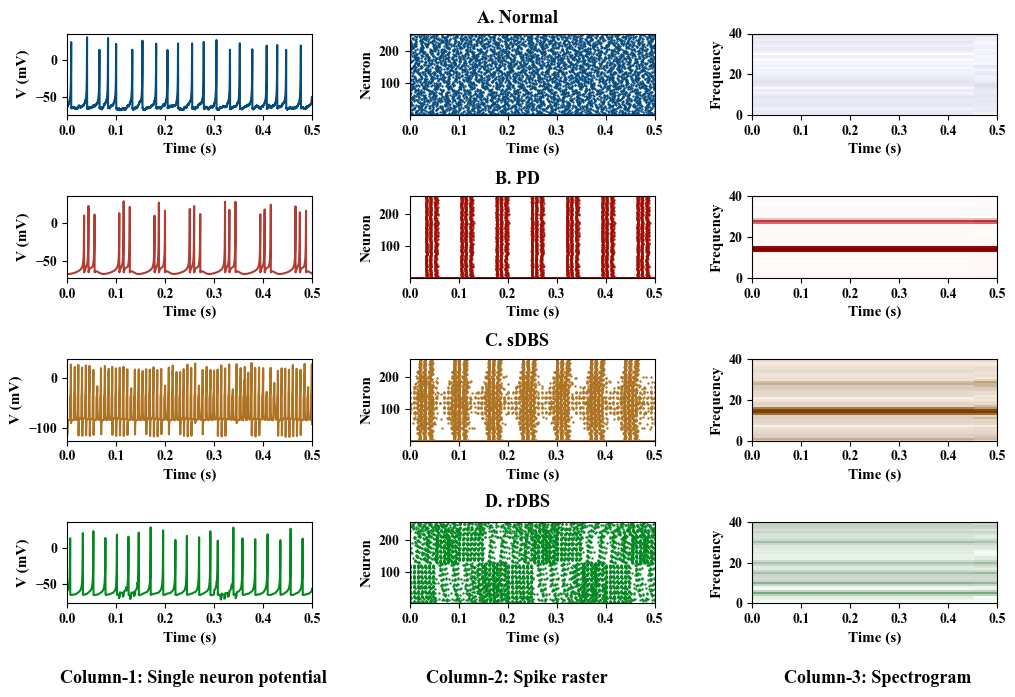

In [16]:
colors_blue = [
    (1, 1, 1),        # Pure white
    (0.98, 0.98, 1),  # Almost white with tiny blue tint
    (0.95, 0.95, 1),  # Very slight blue tint
    (0.9, 0.9, 0.95), # Very slight blue tint,
    (0.8, 0.8, 0.85),
    (0.05, 0.3, 0.7), # Dark blue
    (0, 0.1, 0.5)     # Darker blue
]
cmap_normal = LinearSegmentedColormap.from_list('custom_blues', colors_blue)

colors_red = [
    (1, 1, 1),        # Pure white
    (1, 0.98, 0.98),  # Almost white with tiny red tint
    (1, 0.95, 0.95),  # Very slight red tint
    # (0.95, 0.9, 0.9),
    (0.7, 0.05, 0.05), # Dark red
    (0.5, 0, 0)       # Darker red
]
cmap_PD = LinearSegmentedColormap.from_list('custom_reds', colors_red)


colors_orange = [
    (1, 1, 1),         # Pure white
    (0.99, 0.98, 0.95),# Very light orange tint
    (0.98, 0.95, 0.90),# Light orange tint
    (0.95, 0.9, 0.85),# Light orange tint
    (0.85, 0.8, 0.75),
    (0.678, 0.451, 0.133), # Mid orange - #ad7322
    (0.45, 0.25, 0.05) # Darker orange
]
cmap_std_DBS = LinearSegmentedColormap.from_list('custom_oranges', colors_orange)

colors_green = [
    (1, 1, 1),         # Pure white
    (0.98, 1.0, 0.98), # Very light green tint
    (0.95, 0.99, 0.95),# Light green tint
    (0.85,0.9,0.85),
    (0.75, 0.8, 0.75),
    (0.0118, 0.533, 0.125), # Mid green - #038820
    (0.0, 0.30, 0.07)  # Darker green
]
cmap_sector_DBS = LinearSegmentedColormap.from_list('custom_greens', colors_green)



pd_spec_db = 10 * np.log10(Sxx_stn_PD + 1e-16)   # add tiny eps to avoid log(0)
# optionally restrict to frequency band (e.g. <= 40 Hz)
freq_mask = f_stn_PD <= 40
if np.any(freq_mask):
    pd_vals = pd_spec_db[freq_mask, :].ravel()
else:
    pd_vals = pd_spec_db.ravel()

vmin_spec = np.nanmin(pd_vals)
vmax_spec = np.nanmax(pd_vals)

# Create a Normalize (or use vmin/vmax directly)
from matplotlib.colors import Normalize
common_norm = Normalize(vmin=vmin_spec, vmax=vmax_spec)



fig, axs = plt.subplots(4, 3, figsize=(12, 7.5), facecolor='white', 
                       gridspec_kw={'height_ratios': [1, 1, 1, 1]})
fig.patch.set_visible(True)
fig.patch.set_facecolor('white')
fig.patch.set_edgecolor('white')
fig.patch.set_linewidth(0)

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ce",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


# *************Normal*************
axs[0, 0].plot(t_chunk_normal, V_stn_time_all_normal[t_low_normal:t_high_normal, 15, 15], color=colors['normal'])
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("V (mV)")


spike_array_stn_normal = np.array(spike_monitor_stn_normal[t_low_normal:t_high_normal])
num_neurons_stn_normal = spike_array_stn_normal.shape[1]
time_steps_stn_normal= spike_array_stn_normal.shape[0]
t_raster_normal = np.linspace(0, time_steps_stn_normal * h_normal / 1000, time_steps_stn_normal)
for n in range(num_neurons_stn_normal):
    axs[0, 1].scatter(t_raster_normal, (n + 1) * spike_array_stn_normal[:, n], color=colors['normal'], s=0.5)
axs[0, 1].set_ylim(0.5, num_neurons_stn_normal + 0.5)
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Neuron")


im1 = axs[0, 2].pcolormesh(t_spec_stn_normal, f_stn_normal, 10 * np.log10(Sxx_stn_normal), 
                          cmap=cmap_normal, shading='auto',norm=common_norm)
axs[0, 2].set_ylabel('Frequency')
axs[0, 2].set_xlabel('Time (s)')
axs[0, 2].set_ylim(0, 40)


 # ****************PD*********************
axs[1, 0].plot(t_chunk_PD, V_stn_time_all_PD[t_low_PD:t_high_PD, 15, 15], color=colors['PD'])
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("V (mV)")

spike_array_stn_PD = np.array(spike_monitor_stn_PD[t_low_PD:t_high_PD])
num_neurons_stn_PD = spike_array_stn_PD.shape[1]
time_steps_stn_PD= spike_array_stn_PD.shape[0]
t_raster_PD = np.linspace(0, time_steps_stn_PD * h_PD / 1000, time_steps_stn_PD)
for n in range(num_neurons_stn_PD):
    axs[1, 1].scatter(t_raster_PD, (n + 1) * spike_array_stn_PD[:, n], color=colors['PD'], s=0.5)
axs[1, 1].set_ylim(0.5, num_neurons_stn_PD + 0.5)
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Neuron")


im2 = axs[1, 2].pcolormesh(t_spec_stn_PD, f_stn_PD, 10 * np.log10(Sxx_stn_PD), 
                          cmap=cmap_PD, shading='auto', norm=common_norm)
axs[1, 2].set_ylabel('Frequency')
axs[1, 2].set_xlabel('Time (s)')
axs[1, 2].set_ylim(0, 40)


# ****************std DBS*********************
axs[2, 0].plot(t_chunk_std_DBS, V_stn_time_all_std_DBS[t_low_std_DBS:t_high_std_DBS, 7,8], color=colors['std_DBS'])
axs[2, 0].set_xlabel("Time (s)")
axs[2, 0].set_ylabel("V (mV)")

spike_array_stn_std_DBS = np.array(spike_monitor_stn_std_DBS[t_low_std_DBS:t_high_std_DBS])
num_neurons_stn_std_DBS = spike_array_stn_std_DBS.shape[1]
time_steps_stn_std_DBS= spike_array_stn_std_DBS.shape[0]
t_raster_std_DBS = np.linspace(0, time_steps_stn_std_DBS * h_std_DBS / 1000, time_steps_stn_std_DBS)
for n in range(num_neurons_stn_std_DBS):
    axs[2, 1].scatter(t_raster_std_DBS, (n + 1) * spike_array_stn_std_DBS[:, n], color=colors['std_DBS'], s=0.5)
axs[2, 1].set_ylim(0.5, num_neurons_stn_std_DBS + 0.5)
axs[2, 1].set_xlabel("Time (s)")
axs[2, 1].set_ylabel("Neuron")


im3 = axs[2, 2].pcolormesh(t_spec_stn_std_DBS, f_stn_std_DBS, 10 * np.log10(Sxx_stn_std_DBS), 
                          cmap=cmap_std_DBS, shading='auto', norm=common_norm)
axs[2, 2].set_ylabel('Frequency')
axs[2, 2].set_xlabel('Time (s)')
axs[2, 2].set_ylim(0, 40)

# ******************sector DBS*********************
axs[3, 0].plot(t_chunk_sector_DBS, V_stn_time_all_sector_DBS[t_low_sector_DBS:t_high_sector_DBS, 15, 15], color=colors['sector_DBS'])
axs[3, 0].set_xlabel("Time (s)")
axs[3, 0].set_ylabel("V (mV)")

spike_array_stn_sector_DBS = np.array(spike_monitor_stn_sector_DBS[t_low_sector_DBS:t_high_sector_DBS])
num_neurons_stn_sector_DBS = spike_array_stn_sector_DBS.shape[1]
time_steps_stn_sector_DBS= spike_array_stn_sector_DBS.shape[0]
t_raster_sector_DBS = np.linspace(0, time_steps_stn_sector_DBS * h_sector_DBS / 1000, time_steps_stn_sector_DBS)
for n in range(num_neurons_stn_sector_DBS):
    axs[3, 1].scatter(t_raster_sector_DBS, (n + 1) * spike_array_stn_sector_DBS[:, n], color=colors['sector_DBS'], s=0.5)
axs[3, 1].set_ylim(0.5, num_neurons_stn_sector_DBS + 0.5)
axs[3, 1].set_xlabel("Time (s)")
axs[3, 1].set_ylabel("Neuron")


im4 = axs[3, 2].pcolormesh(t_spec_stn_sector_DBS, f_stn_sector_DBS, 10 * np.log10(Sxx_stn_sector_DBS), 
                          cmap=cmap_sector_DBS, shading='auto',norm=common_norm)
axs[3, 2].set_ylabel('Frequency')
axs[3, 2].set_xlabel('Time (s)')
axs[3, 2].set_ylim(0, 40)

# legend_elements = [
        # Line2D([0], [0], color=colors['normal'], label='Normal', linewidth=3),
        # Line2D([0], [0], color=colors['PD'], label='PD', linewidth=3),
        # Line2D([0], [0], color=colors['std_DBS'], label='Standard DBS', linewidth=3),
        # Line2D([0], [0], color=colors['sector_DBS'], label='Sector DBS', linewidth=3)
# ]
# 
# Add legend at the bottom of the figure
# fig.legend(handles=legend_elements, 
        #   loc='center', 
        #   bbox_to_anchor=(0.5, -0.02),
        #   ncol=4,  # Place elements side by side
        #   frameon=False,
        #   handlelength=1.5,
        #   fontsize=14)  # Length of the lines
# 
# labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
# for n, ax in enumerate(axs.flat):
    # ax.text(-0.1, 1.25, labels[n], transform=ax.transAxes, 
            # fontsize=14, fontweight='bold', va='top', ha='right')


for ax in {axs[0, 0], axs[1, 0], axs[2, 0], axs[3, 0],
           axs[0, 1], axs[1, 1], axs[2, 1], axs[3, 1]}:
    ax.set_xlim(0,0.5)

for ax in [axs[0, 2], axs[1, 2], axs[2, 2], axs[3, 2]]:
    ax.set_xlim(0.5, 1)

# remap time ticks for all spectrograms (3rd column)
tick_positions = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
tick_labels   = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5"]


for ax in axs[:, 2]:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)



row_titles = [
    r"A. Normal",
    r"B. PD",
    r"C. sDBS",
    r"D. rDBS"
]


for i, title in enumerate(row_titles):
    fig.text(
        0.5,                     # center horizontally
        0.9 - i * 0.215,        # vertical placement per row
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


column_titles = [
    "Column-1: Single neuron potential",
    "Column-2: Spike raster",
    "Column-3: Spectrogram"
]


# x positions of the 3 columns (figure coordinates)
x_positions = [0.18, 0.45, 0.75]


for x, title in zip(x_positions, column_titles):
    fig.text(
        x+ 0.05,
        0.02,             
        title,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


plt.subplots_adjust(wspace=0.4, hspace=1, bottom = 0.12)

# Save figs
fig.set_rasterized(True)
plt.savefig("STN_GPe_all_conditions.svg", format="svg",  bbox_inches="tight",pad_inches=0.05)
plt.savefig("STN_GPe_all_conditions.png", format="png", bbox_inches="tight",pad_inches=0.05)
plt.savefig("STN_GPe_all_conditions.pdf", format="pdf", bbox_inches="tight",pad_inches=0.05)
plt.savefig("STN_GPe_all_conditions.tiff",format="tiff",dpi=600,bbox_inches="tight",pad_inches=0.05)
plt.savefig("STN_GPe_all_conditions.eps",format="eps",bbox_inches="tight",pad_inches=0.05)

plt.show()


In [12]:

# Print metrics in table format
print(f'|{"Metric":<15}|{"Normal":^10}|{"PD":^10}|{"std DBS":^10}|{"Sector DBS":^10}|')
print(f'|{"-"*15}|{"-"*10}|{"-"*10}|{"-"*10}|{"-"*10}|')
print(f'|{"Entropy":<15}|{avg_entropy_stn_normal:^10.3f}|{avg_entropy_stn_PD:^10.3f}|{avg_entropy_stn_std_DBS:^10.3f}|{avg_entropy_stn_sector_DBS:^10.3f}|')
print(f'|{"Synchrony":<15}|{Ravg_stn_normal:^10.3f}|{Ravg_stn_PD:^10.3f}|{Ravg_stn_std_DBS:^10.3f}|{Ravg_stn_sector_DBS:^10.3f}|')
# print(f'|{"Frequency":<15}|{frequency_avg_STN:^10.3f}|{frequency_avg_GPe:^10.3f}|')
print(f'|{"Rate std":<15}|{mean_std_normal:^10.2f}|{mean_std_PD:^10.2f}|{mean_std_std_DBS:^10.2f}|{mean_std_sector_DBS:^10.2f}|')  
print(f'|{"Rate std min":<15}|{min_std_normal:^10.2f}|{min_std_PD:^10.2f}|{min_std_std_DBS:^10.2f}|{min_std_sector_DBS:^10.2f}|')  
print(f'|{"Rate std max":<15}|{max_std_normal:^10.2f}|{max_std_PD:^10.2f}|{max_std_std_DBS:^10.2f}|{max_std_sector_DBS:^10.2f}|')  


|Metric         |  Normal  |    PD    | std DBS  |Sector DBS|
|---------------|----------|----------|----------|----------|
|Entropy        |  0.575   |  0.310   |  0.339   |  0.821   |
|Synchrony      |  0.107   |  0.922   |  0.625   |  0.250   |
|Rate std       |   0.32   |   0.06   |   0.12   |   0.33   |
|Rate std min   |   0.06   |   0.00   |   0.02   |   0.33   |
|Rate std max   |   0.33   |   0.15   |   0.33   |   0.33   |
